In [16]:
### Implement ReAct with LangGraph
import os
import re
import requests
from langchain.tools import tool
import arxiv as arxiv_lib
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler
from langchain.agents import create_agent
from langchain_core.tools import Tool
from langchain_tavily import TavilySearch
from langchain_community.vectorstores import FAISS
from langchain_openai.embeddings import OpenAIEmbeddings
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model


In [3]:
load_dotenv()

langfuse_trace = CallbackHandler()

In [14]:
# Cấu hình tra cứu arxiv


ARXIV_TOP_K = 2          # số kết quả trả về
ARXIV_MAX_CHARS = 500    # độ dài tối đa của summary mỗi bài

# Regex nhận diện arXiv ID (vd: 1706.03762, hep-th/9901001) để tra theo id thay vì full-text
_ARXIV_ID = re.compile(r"\d{4}\.\d{4,5}(v\d+)?$|[a-z\-]+(\.[A-Z]{2})?/\d{7}(v\d+)?$")
_arxiv_client = arxiv_lib.Client()


@tool
def arxiv(query: str) -> str:
    """
    Search arXiv for academic and scientific research papers.

    Best used for research topics, paper summaries, literature reviews,
    machine learning, AI, computer science, mathematics, and physics.

    Input: a research query, paper title, keyword, or arXiv ID.
    Output: publication date, title, authors, and paper abstract.
    """
    if _ARXIV_ID.match(query.strip()):
        search = arxiv_lib.Search(id_list=query.split(), max_results=ARXIV_TOP_K)
    else:
        search = arxiv_lib.Search(
            query=query[:300],
            max_results=ARXIV_TOP_K,
            sort_by=arxiv_lib.SortCriterion.Relevance,
        )
    docs = []
    for r in _arxiv_client.results(search):
        authors = ", ".join(a.name for a in r.authors)
        docs.append(
            f"Published: {r.published.date()}\n"
            f"Title: {r.title}\n"
            f"Authors: {authors}\n"
            f"Summary: {r.summary[:ARXIV_MAX_CHARS]}"
        )
    return "\n\n".join(docs) if docs else "No good arXiv results found."


print(arxiv.name)

arxiv


In [10]:
# Cấu hình tra cứu Wikipedia

WIKI_TOP_K = 1           # số trang trả về
WIKI_MAX_CHARS = 500     # độ dài tối đa của summary mỗi trang
WIKI_LANG = "en"         # ngôn ngữ (vd: "en", "vi")

_WIKI_API = f"https://{WIKI_LANG}.wikipedia.org/w/api.php"
# Wikimedia yêu cầu User-Agent mô tả rõ ứng dụng; thiếu nó dễ bị chặn -> response rỗng -> JSONDecodeError
_WIKI_HEADERS = {"User-Agent": "ultimate-rag-bootcamp/1.0 (educational project)"}

@tool
def wiki(query: str) -> str:
    """
    Search Wikipedia for factual information and encyclopedia-style summaries.

    Best used for general knowledge, people, places, organizations,
    historical events, scientific concepts, and topic overviews.

    Input: a search query.
    Output: the most relevant Wikipedia page title and summary.
    """

    # 1) Tìm các trang khớp với truy vấn
    resp = requests.get(
        _WIKI_API,
        params={"action": "query", "list": "search", "srsearch": query,
                "srlimit": WIKI_TOP_K, "format": "json"},
        headers=_WIKI_HEADERS, timeout=10,
    )
    resp.raise_for_status()
    hits = resp.json().get("query", {}).get("search", [])
    if not hits:
        return "No good Wikipedia Search Result was found"

    # 2) Lấy phần tóm tắt (plain text) cho từng trang
    docs = []
    for hit in hits:
        title = hit["title"]
        page = requests.get(
            _WIKI_API,
            params={"action": "query", "prop": "extracts", "explaintext": 1,
                    "titles": title, "redirects": 1, "format": "json"},
            headers=_WIKI_HEADERS, timeout=10,
        )
        page.raise_for_status()
        pages = page.json().get("query", {}).get("pages", {})
        extract = next(iter(pages.values()), {}).get("extract", "")
        docs.append(f"Page: {title}\nSummary: {extract[:WIKI_MAX_CHARS]}")
    return "\n\n".join(docs)

print(wiki.name)

wiki


In [ ]:
tavily = TavilySearch(max_results=2)

@tool
def web_search(query: str) -> str:
    """
    Search the web for current and real-time information.

    Best used for news, recent developments, live events,
    trending topics, and up-to-date information.

    Input: a search query.
    Output: summarized web search results with source links.
    """
    # TavilySearch.invoke() trả về dict {"query", "results", "answer", ...},
    # danh sách kết quả nằm trong khóa "results".
    response = tavily.invoke(query)
    results = response.get("results", []) if isinstance(response, dict) else response

    docs = []
    for item in results:
        docs.append(
            f"Title: {item.get('title', '')}\n"
            f"Content: {item.get('content', '')}\n"
            f"URL: {item.get('url', '')}"
        )

    return "\n\n".join(docs) if docs else "No relevant web results found."


In [4]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = OllamaEmbeddings(
    model="nomic-embed-text"
)
vectorstore = FAISS.from_documents(chunks, embedding=embedding)
retriever  = vectorstore.as_retriever()

In [5]:
retriever.invoke("what are autonomous agents")

[Document(id='69ded3bf-5de2-4d6e-8c3d-7860540d47c7', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [6]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [7]:
retriever_tool_func("what are autonomous agents")

📚 Using RAGRetriever tool


"Tool use\n\nThe agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), including current information, code execution capability, access to proprietary information sources and more.\n\n\n\n\n\nOverview of a LLM-powered autonomous agent system.\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\nCitation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\nLLM Powered Autonomous Agents

In [ ]:
retriever_tool = Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relavant knowledge base info",
    func=retriever_tool_func,
)
type(retriever_tool)


langchain_core.tools.simple.Tool

In [15]:
type(wiki), type(arxiv)

(langchain_core.tools.structured.StructuredTool,
 langchain_core.tools.structured.StructuredTool)

In [28]:
llm_ollama = init_chat_model(
    model="granite4",
    model_provider="ollama"
)

llm_openai = init_chat_model(
    # model="gpt-4.1-nano",
    model="gpt-4o-mini",
    model_provider="openai"
)

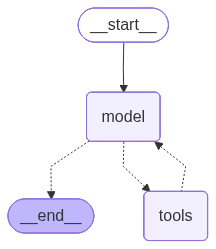

In [29]:
### 2. Define the agent node

tools = [retriever_tool,  wiki]

## create the native Langgraph react agent
react_node = create_agent(
    # llm_ollama,
    llm_openai,
    tools=tools
)
react_node

In [30]:
### 3. LangGraph Agent State

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

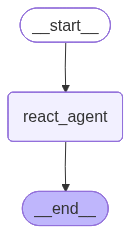

In [31]:
### 4. Build Graph

builder = StateGraph(AgentState)
builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [32]:
### Openai Agent

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {
        "messages": [
            HumanMessage(content=user_query)
        ]
    }
    result = graph.invoke(state, config={"callbacks": [langfuse_trace]})

    print("\n✅ Final Answer:\n", result["messages"][-1].content)


📚 Using RAGRetriever tool

✅ Final Answer:
 ### Agent Loop

An **agent loop** refers to the iterative process in which an autonomous agent interacts with its environment to achieve specific goals. During this loop, the agent perceives its environment, decides on actions based on its internal reasoning or learning algorithms, and then executes those actions, leading to changes in the environment. This cycle repeats as the agent gathers information and refines its understanding and strategies over time.

In the context of modern AI systems, such as those empowered by large language models (LLMs), an agent can call external APIs to retrieve missing information, allowing it to perform complex tasks that require real-time data or actions beyond its pre-trained capabilities. The agent learns and adapts through these interactions.

### Autonomous Agents

According to Wikipedia, an **autonomous agent** is an artificial intelligence (AI) system capable of performing complex tasks independently.

In [22]:
### 5. Run the React Agent

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {
        "messages": [
            HumanMessage(content=user_query)
        ]
    }
    result = graph.invoke(state, config={"callbacks": [langfuse_trace]})

    print("\n✅ Final Answer:\n", result["messages"][-1].content)


📚 Using RAGRetriever tool

✅ Final Answer:
 **Agent Loop**

An **agent loop** is a recurring cycle or feedback mechanism that enables an autonomous agent—such as one built with large language models (LLMs)—to continuously interact, learn, and adapt to its environment. The loop typically involves:

1. **Perception**: Gathering input from the world (e.g., user queries, sensor data).  
2. **Planning/Decision‑Making**: Using a model to formulate an action or response based on that perception.  
3. **Action Execution**: Carrying out the plan (e.g., invoking APIs, updating state, generating output).  
4. **Feedback Integration**: Incorporating results of actions back into the system’s knowledge and refining future plans.

This loop lets the agent learn from its experiences, update its internal models or tool usage, and respond more effectively over time—often without explicit re‑training on a static dataset.

---

**Wikipedia Description of Autonomous Agents**

*Source: Wikipedia article tit